In [1]:
import sys
import os
import glob

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import datetime as dt8
import math
import matplotlib.pyplot as plt
import decimal

import dabest
import warnings
import plotly.express as px 
import plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio




warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
openPath = "D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\New optogenetics\\TruMelan\\"
#openPath = "C:\\Users\\labuser\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\New optogenetics\\TruMelan\\"

files = os.listdir(openPath)

print (files)

['AL_duration.csv', 'AL_light.csv', 'ChaT x eOPN3', 'ChaT x eOPN3_part1.zip', 'exec_duration.csv', 'exec_light.csv', 'speed_duration.csv', 'speed_light.csv', 'State_duration.csv', 'State_light.csv', 'Time_to_be_Loc_duration.csv', 'Time_to_be_Loc_light.csv', 'Time_to_not_be_SS_duration.csv', 'Time_to_not_be_SS_light.csv']


In [3]:
f = os.path.join(openPath, 'speed_duration.csv')
df=pd.read_csv(f)
df2 = df.drop(df.columns[[0]],axis = 1)

In [4]:
time_0 = df2.iloc[0:1200, :].reset_index()
time_03 = df2.iloc[1200:1201, :].reset_index()
dark_03 = df2.iloc[1200:4800, :].reset_index()
time_05 = df2.iloc[4800:4801, :].reset_index()
dark_05 = df2.iloc[4800:8400, :].reset_index()
time_1 = df2.iloc[8400:8401, :].reset_index()
dark_1 = df2.iloc[8402:12002, :].reset_index()
time_3 = df2.iloc[12002:12005, :].reset_index()
dark_3 = df2.iloc[12005:15605, :].reset_index()
time_5 = df2.iloc[15605:15610, :].reset_index()
dark_5 = df2.iloc[15610:19208, :].reset_index()

In [156]:
df88=pd.DataFrame()
df88['Mean'] = df2['Mean'].groupby(np.arange(len(df2))//60).mean()
df88['SEM'] = df2['SEM'].groupby(np.arange(len(df2))//60).mean() #minutesdataframe

time_0 = df88.iloc[0:20].reset_index()
#time_03 = df2.iloc[20:1201/60, :].reset_index()
dark_03 = df88.iloc[20:80].reset_index()
#time_05 = df2.iloc[4800/60:4801/60, :].reset_index()
dark_05 = df88.iloc[80:140].reset_index()
#time_1 = df88.iloc[140:141].reset_index()
dark_1 = df88.iloc[140:200].reset_index()
#time_3 = df88.iloc[201:204].reset_index()
dark_3 = df88.iloc[200:260].reset_index()
#time_5 = df88.iloc[264:269].reset_index()
dark_5 = df88.iloc[261:321].reset_index()

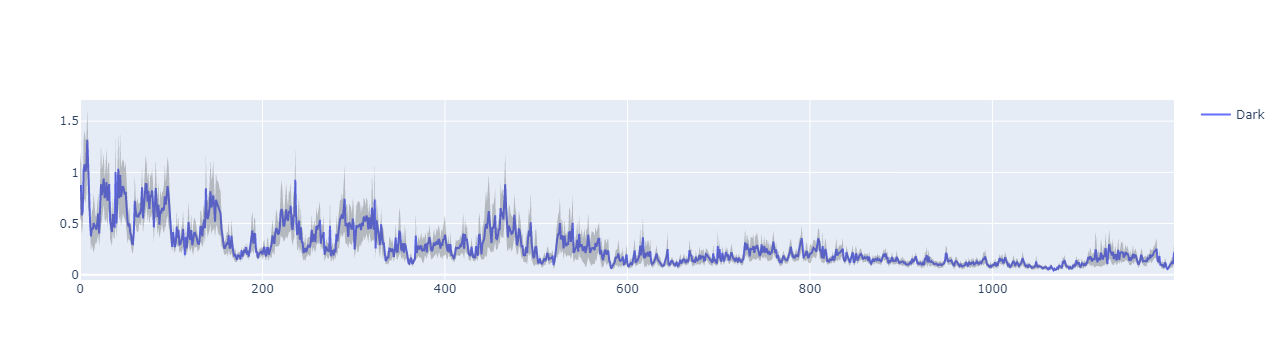

In [19]:
fig = go.Figure()

#Dark
fig.add_trace(go.Scatter
        (x =np.arange(0,len(time_0),1),
        y= time_0['Mean'], 
        mode='lines', 
        name='Dark'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(time_0),1),
        y=(time_0['Mean'] + time_0['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(time_0),1),
        y=(time_0['Mean'] - time_0['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(68, 68, 68, 0.3)',
        fill='tonexty',
        showlegend=False))

#0.3


In [5]:
c1 = 'rgba(99, 110, 250, 1)'
c2 = 'rgba(171, 99, 250, 1)'
c3 = 'rgba(239, 85, 59, 1)'
c4 = 'rgba(254, 203, 82, 1)'
c5 = 'rgba(0, 204, 150, 1)'

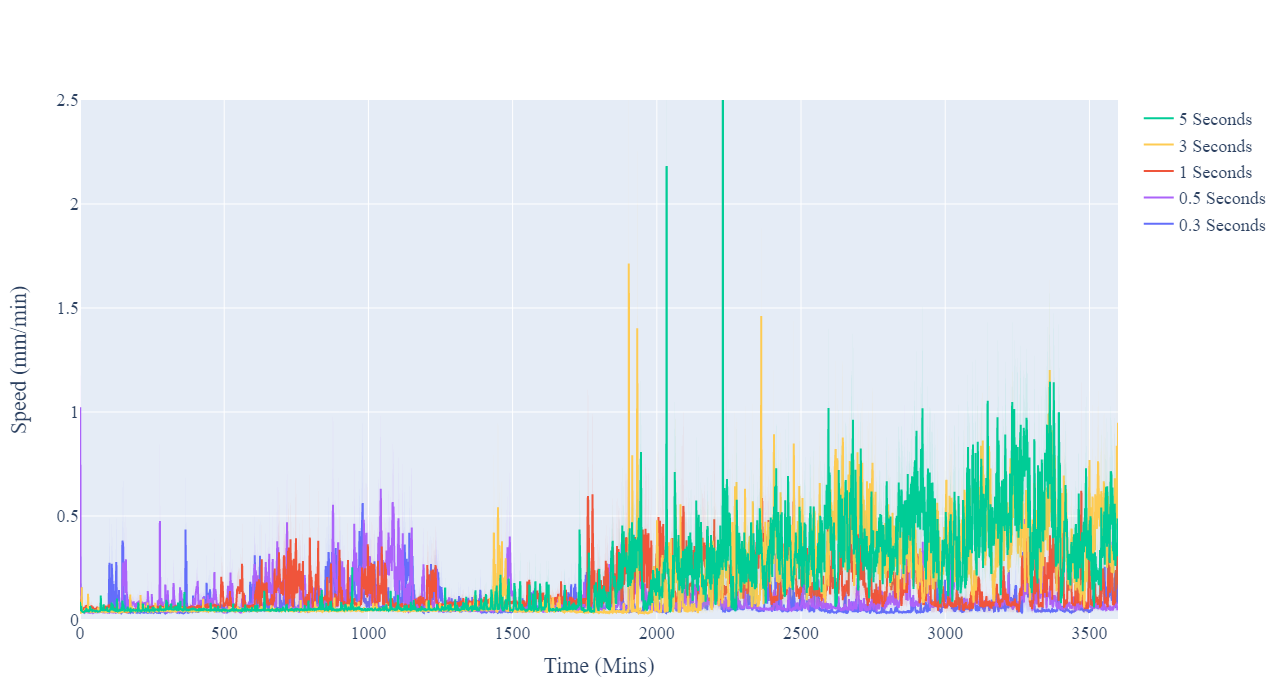

In [7]:
fig = go.Figure()

#0.3s
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_03),1),
        y= dark_03['Mean'], marker_color = c1,
        mode='lines', 
        name='0.3 Seconds'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_03),1),
        y=(dark_03['Mean'] + dark_03['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_03),1),
        y=(dark_03['Mean'] - dark_03['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(99, 110, 250, 0.1)',
        fill='tonexty',
        showlegend=False))


#0.5s
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_05),1),
        y= dark_05['Mean'],
        mode='lines', marker_color = c2,
        name='0.5 Seconds'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_05),1),
        y=(dark_05['Mean'] + dark_05['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_05),1),
        y=(dark_05['Mean'] - dark_05['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(171, 99, 250, 0.1)',
        fill='tonexty',
        showlegend=False))

#1s
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_05),1),
        y= dark_1['Mean'],
        mode='lines', marker_color = c3,
        name='1 Seconds'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_1),1),
        y=(dark_1['Mean'] + dark_1['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_1),1),
        y=(dark_1['Mean'] - dark_1['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(239, 85, 59, 0.1)',
        fill='tonexty',
        showlegend=False))

#3s
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_05),1),
        y= dark_3['Mean'],
        mode='lines', marker_color = c4,
        name='3 Seconds'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_3),1),
        y=(dark_3['Mean'] + dark_3['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_3),1),
        y=(dark_3['Mean'] - dark_3['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(254, 203, 82, 0.1)',
        fill='tonexty',
        showlegend=False))

#5s
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_5),1),
        y= dark_5['Mean'],
        mode='lines', marker_color = c5,
        name='5 Seconds'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_5),1),
        y=(dark_5['Mean'] + dark_5['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_5),1),
        y=(dark_5['Mean'] - dark_5['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(0, 204, 150, 0.1)',
        fill='tonexty',
        showlegend=False))

fig.update_xaxes(title_text = "Time (Mins)")
#fig.update_yaxes(title_text = "Activity level",range=[0,700],tickvals=np.arange(0,800,100))
fig.update_yaxes(title_text = "Speed (mm/min)",range=[0,2.5],tickvals=np.arange(0,3,0.5))

fig.update_layout(font=dict(family="ibm plex sans",size=18,),height=700, width=1200)

fig.show()

fig.write_image("D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\New optogenetics\\TruMelan\\test.svg")

In [159]:
g = os.path.join(openPath, 'AL_light.csv')
df_L=pd.read_csv(g)
df3 = df_L.drop(df_L.columns[[0]],axis = 1)

dark_0 = df3.iloc[0:1800, :].reset_index()
light_8 = df3.iloc[1800:1801, :].reset_index()
dark_8 = df3.iloc[1801:3601, :].reset_index()
light_4 = df3.iloc[3601:3602, :].reset_index()
dark_4 = df3.iloc[3602:5402, :].reset_index()
light_2 = df3.iloc[5402:5403, :].reset_index()
dark_2 = df3.iloc[5403:7203, :].reset_index()
light_1 = df3.iloc[7203:7204, :].reset_index()
dark_F = df3.iloc[7204:9004, :].reset_index()

In [160]:
df88=pd.DataFrame()
df88['Mean'] = df3['Mean'].groupby(np.arange(len(df3))//60).mean()
df88['SEM'] = df3['SEM'].groupby(np.arange(len(df3))//60).mean() #minutesdataframe

dark_0 = df88.iloc[0:30, :].reset_index()
dark_8 = df88.iloc[30:60, :].reset_index()
dark_4 = df88.iloc[60:90, :].reset_index()
dark_2 = df88.iloc[90:120, :].reset_index()
dark_F = df88.iloc[120:150, :].reset_index()

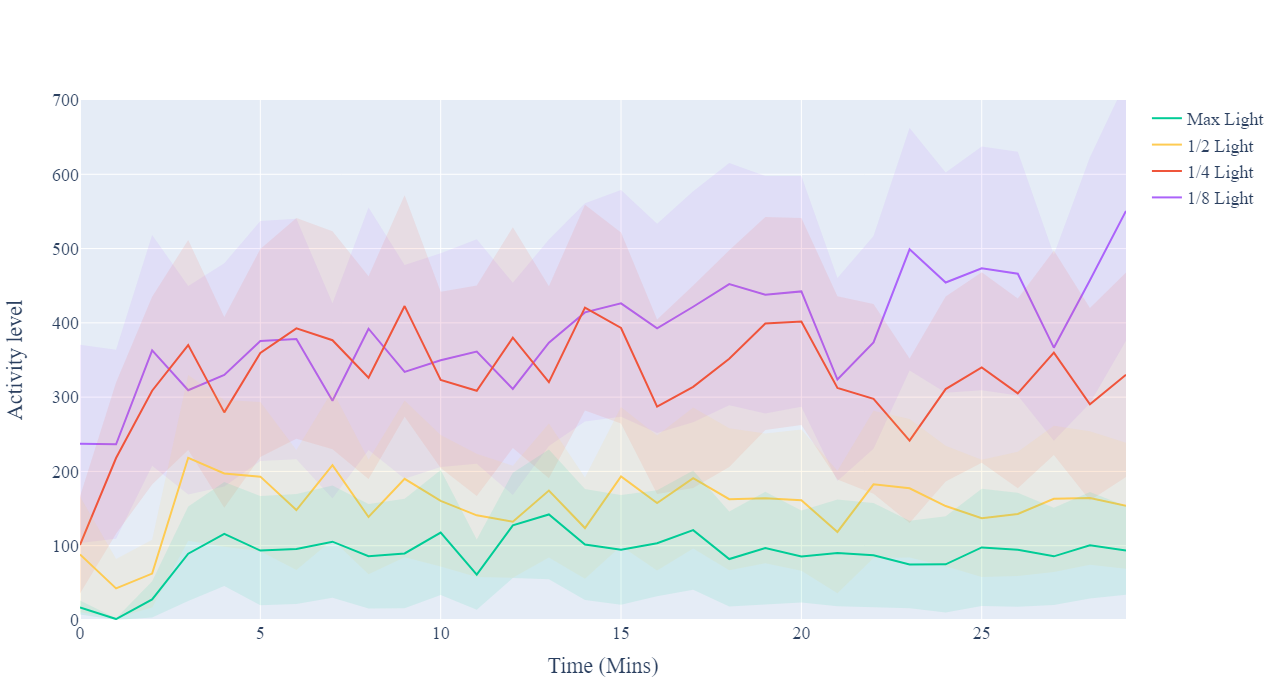

In [163]:
fig = go.Figure()

#Dark
# fig.add_trace(go.Scatter
#         (x =np.arange(0,len(dark_0),1),
#         y= dark_0['Mean'],
#         mode='lines', 
#          marker_color = c1,
#         name='Dark'))

# fig.add_trace(go.Scatter(
#         name='Upper Bound of dark',
#         x =np.arange(0,len(dark_0),1),
#         y=(dark_0['Mean'] + dark_0['SEM']),
#         mode='lines',
#         marker=dict(color="#444"),
#         line=dict(width=0),
#         showlegend=False))
                 
# fig.add_trace(go.Scatter(
#         name='Lower Bound of dark',
#         x =np.arange(0,len(dark_0),1),
#         y=(dark_0['Mean'] - dark_0['SEM']),
#         marker=dict(color="#444"),
#         line=dict(width=0),
#         mode='lines',
#         fillcolor='rgba(99, 110, 250, 0.1)',
#         fill='tonexty',
#         showlegend=False))


#1/8
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_05),1),
        y= dark_8['Mean'],
        mode='lines',  marker_color = c2,
        name='1/8 Light'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_8),1),
        y=(dark_8['Mean'] + dark_8['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_8),1),
        y=(dark_8['Mean'] - dark_8['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(171, 99, 250, 0.1)',
        fill='tonexty',
        showlegend=False))

#1/4
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_4),1),
        y= dark_4['Mean'],
        mode='lines',  marker_color = c3,
        name='1/4 Light'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_4),1),
        y=(dark_4['Mean'] + dark_4['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_4),1),
        y=(dark_4['Mean'] - dark_4['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(239, 85, 59, 0.1)',
        fill='tonexty',
        showlegend=False))
#1/2 light
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_2),1),
        y= dark_2['Mean'],
        mode='lines', marker_color = c4,
        name='1/2 Light'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_2),1),
        y=(dark_2['Mean'] + dark_2['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_2),1),
        y=(dark_2['Mean'] - dark_2['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(254, 203, 82, 0.1)',
        fill='tonexty',
        showlegend=False))

#Full
fig.add_trace(go.Scatter
        (x =np.arange(0,len(dark_F),1),
        y= dark_F['Mean'],
        mode='lines', marker_color = c5,
        name='Max Light'))

fig.add_trace(go.Scatter(
        name='Upper Bound of dark',
        x =np.arange(0,len(dark_F),1),
        y=(dark_F['Mean'] + dark_F['SEM']),
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False))
                 
fig.add_trace(go.Scatter(
        name='Lower Bound of dark',
        x =np.arange(0,len(dark_F),1),
        y=(dark_F['Mean'] - dark_F['SEM']),
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(0, 204, 150, 0.1)',
        fill='tonexty',
        showlegend=False))



fig.update_xaxes(title_text = "Time (Mins)")
#fig.update_yaxes(title_text = "Speed (mm/min)",range=[0,2.5],tickvals=np.arange(0,3,0.5))
fig.update_yaxes(title_text = "Activity level",range=[0,700],tickvals=np.arange(0,800,100))

#,range=[0,600],tickvals=np.arange(0,700,100)

fig.update_layout(font=dict(family="ibm plex sans",size=18,),height=700, width=1200)

fig.write_image("C:\\Users\\labuser\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\New optogenetics\\TruMelan\\ChaT x eOPN3\\AL_light_all_60_wo_dark.svg")

fig.show()

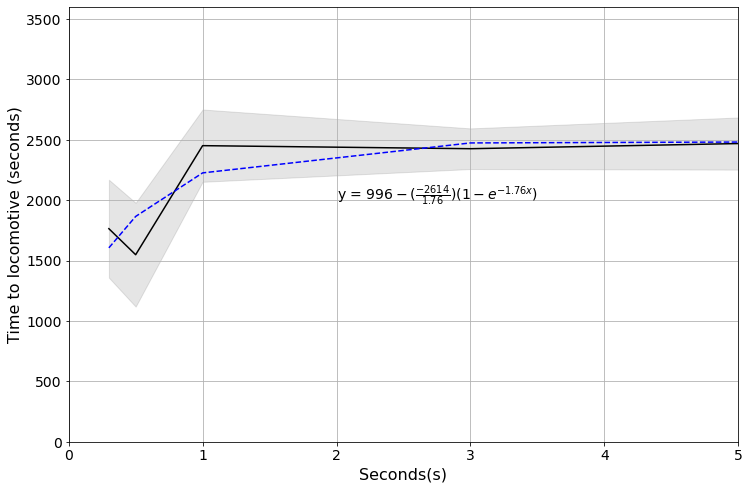

In [53]:
import operator
import math

h = os.path.join(openPath, 'Time_to_be_Loc_duration.csv')
df_h=pd.read_csv(h)
df4 = df_h.drop(df_h.columns[[0,1]],axis = 1)

mean= df4.mean(axis=0)
sem = df4.sem(axis=0)
lst = []
for n in mean:
    lst.append(n)

semm = []
for nn in sem:
    semm.append(nn)

ci_lower = list(map(operator.sub, lst, semm))
ci_upper = list(map(operator.add, lst, semm))

xax = [0.3, 0.5, 1, 3, 5]
yax = lst

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(12, 8)

ax.plot(xax, yax, color = 'k')
ax.fill_between(xax, ci_lower, ci_upper, color='k', alpha=.1)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.xlabel('Seconds(s)', size = 16)
plt.xlim(0,5)
plt.ylim(0,3600)
plt.ylabel('Time to locomotive (seconds)', size = 16)

ax.grid(visible=True, which='major')
ax.grid(visible=True, which='minor')

#996.4262 - (-2613.963/1.757148)*(1 - e^(-1.757148*x))
eqn= []
for num in xax:
    vv = -1.76*num
    exax = math.exp(vv)
    eqn.append(996.4 - (-2614/1.76)*(1 - exax))

ax.plot(xax, eqn,"b--")
ax.text(2, 2000, r'y = $996 - (\frac{-2614}{1.76})(1 - e^{-1.76x})$', fontsize=14)

plt.show()

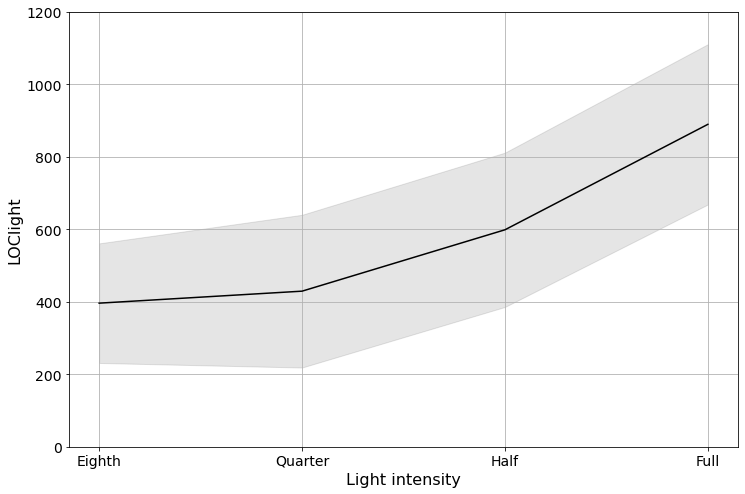

In [36]:
import operator

j = os.path.join(openPath, 'Time_to_be_Loc_light.csv')
df_j=pd.read_csv(j)
df5 = df_j.drop(df_j.columns[[0,1]],axis = 1)


mean= df5.mean(axis=0)
sem = df5.sem(axis=0)
lst = []
for n in mean:
    lst.append(n)

semm = []
for nn in sem:
    semm.append(nn)

ci_lower = list(map(operator.sub, lst, semm))
ci_upper = list(map(operator.add, lst, semm))

xax = ["Eighth", "Quarter", "Half", "Full"]
yax = lst

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(12, 8)
ax.plot(xax, yax, color = 'k')
ax.fill_between(xax, ci_lower, ci_upper, color='k', alpha=.1)


plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.xlabel('Light intensity', size = 16)
plt.ylim(0,1200)
plt.ylabel('LOClight', size = 16)

ax.grid(visible=True, which='major')
ax.grid(visible=True, which='minor')



#cubic polynomial: y = 419.5931 - 454.9697*x + 2328.485*x^2 - 1403.29*x^3

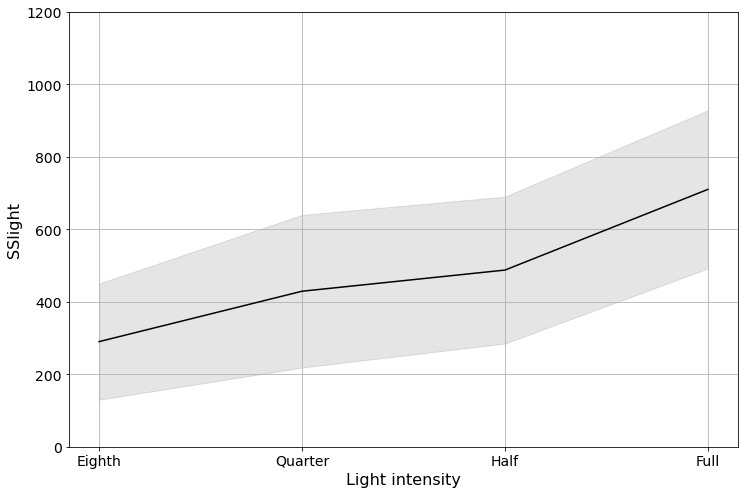

In [176]:
import operator

k = os.path.join("D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\New optogenetics\\TruMelan\\", 'Time_to_not_be_SS_light.csv')
df_k=pd.read_csv(k)
df6 = df_k.drop(df_k.columns[[0,1]],axis = 1)


mean= df6.mean(axis=0)
sem = df6.sem(axis=0)
lst = []
for n in mean:
    lst.append(n)

semm = []
for nn in sem:
    semm.append(nn)

ci_lower = list(map(operator.sub, lst, semm))
ci_upper = list(map(operator.add, lst, semm))

xax = ["Eighth", "Quarter", "Half", "Full"]
yax = lst

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(12, 8)
ax.plot(xax, yax, color = 'k')
ax.fill_between(xax, ci_lower, ci_upper, color='k', alpha=.1)


plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.xlabel('Light intensity', size = 16)
plt.ylim(0,1200)
plt.ylabel('SSlight', size = 16)

ax.grid(visible=True, which='major')
ax.grid(visible=True, which='minor')

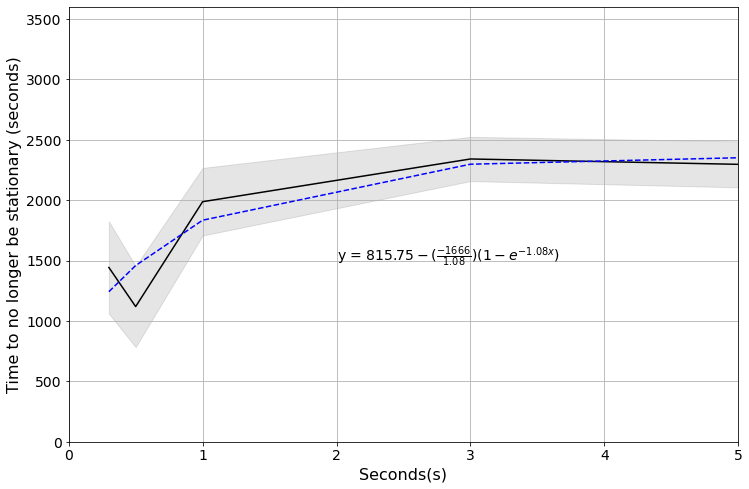

In [60]:
import operator

m = os.path.join(openPath, 'Time_to_not_be_SS_duration.csv')
df_m=pd.read_csv(m)
df7 = df_m.drop(df_m.columns[[0,1]],axis = 1)

mean= df7.mean(axis=0)
sem = df7.sem(axis=0)
lst = []
for n in mean:
    lst.append(n)

semm = []
for nn in sem:
    semm.append(nn)

ci_lower = list(map(operator.sub, lst, semm))
ci_upper = list(map(operator.add, lst, semm))

xax = [0.3, 0.5, 1, 3, 5]
yax = lst

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(12, 8)


ax.plot(xax, yax, color = 'k')
ax.fill_between(xax, ci_lower, ci_upper, color='k', alpha=.1)


plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.xlabel('Seconds(s)', size = 16)
plt.xlim(0,5)
plt.ylim(0,3600)
plt.ylabel('Time to no longer be stationary (seconds)', size = 16)

ax.grid(visible=True, which='major')
ax.grid(visible=True, which='minor')

#equation: y = 815.7456 - (-1666.012/1.079278)*(1 - e^(-1.079278*x))

eqn= []
for num in xax:
    vv = -1.08*num
    exax = math.exp(vv)
    eqn.append(815.75 - (-1666/1.08)*(1 - exax))

ax.text(2, 1500, r'y = $815.75 - (\frac{-1666}{1.08})(1 - e^{-1.08x})$', fontsize=14)

ax.plot(xax, eqn,"b--")


In [ ]:
#https://mycurvefit.com/